# PetroChain — Training Notebook

**Tujuan:** Melatih model klasifikasi level kelayakan subsidi BBM warga berdasarkan fitur sosial-ekonomi.

**Dataset:** Sintetis berbasis distribusi Susenas BPS Aceh (bukan data NIK asli).

**Label:**
- `1` = Miskin Ekstrem → kuota 150 liter/bulan
- `2` = Miskin → kuota 80 liter/bulan  
- `3` = Rentan Miskin → kuota 50 liter/bulan

**Model yang dibandingkan:**
1. XGBoost (model utama produksi)
2. LightGBM
3. Random Forest
4. Logistic Regression (baseline)

## 1. Setup & Import

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)

# Output dir
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

print('[OK] Library berhasil di-import')
print(f'Model akan disimpan di: {MODEL_DIR.resolve()}')

[OK] Library berhasil di-import
Model akan disimpan di: E:\KMIPN\PETROCHAIN\ml-service\models


## 2. Generate Dataset Sintetis

Dataset dibangkitkan berdasarkan distribusi realistis Susenas BPS Aceh.
Distribusi kelas: Level 1 (25%) · Level 2 (45%) · Level 3 (30%) — mencerminkan realitas lapangan.

In [93]:
def compute_engineered_features(X_base: np.ndarray) -> np.ndarray:
    """
    Tambahkan 5 fitur turunan dari 8 fitur dasar.
    
    Input X_base kolom (index):
        0: kondisi_rumah (1-5)
        1: sumber_listrik (1-4)
        2: kepemilikan_aset (1-4)
        3: pendidikan_kk (1-6)
        4: jml_tanggungan (0-12)
        5: jenis_pekerjaan (1-6)
        6: akses_air (1-4)
        7: kepemilikan_lahan (1-3)
    
    Output: X_base + 5 kolom baru (total 13 kolom)
    """
    kondisi_rumah     = X_base[:, 0]
    sumber_listrik    = X_base[:, 1]
    kepemilikan_aset  = X_base[:, 2]
    pendidikan_kk     = X_base[:, 3]
    jml_tanggungan    = X_base[:, 4]
    jenis_pekerjaan   = X_base[:, 5]
    akses_air         = X_base[:, 6]
    kepemilikan_lahan = X_base[:, 7]

    # 1. Skor kerentanan (weighted sum — semakin tinggi = semakin baik)
    skor_kerentanan = (
        kondisi_rumah * 2.0 +
        sumber_listrik * 1.5 +
        kepemilikan_aset * 2.5 +
        pendidikan_kk * 1.0 +
        jenis_pekerjaan * 2.0 +
        akses_air * 1.5 +
        kepemilikan_lahan * 2.0 -
        jml_tanggungan * 1.5
    )

    # 2. Rasio tanggungan terhadap aset
    rasio_tanggungan_aset = jml_tanggungan / (kepemilikan_aset + kepemilikan_lahan + 0.5)

    # 3. Skor infrastruktur
    skor_infrastruktur = sumber_listrik + akses_air

    # 4. Skor ekonomi
    skor_ekonomi = jenis_pekerjaan + kepemilikan_aset + kepemilikan_lahan

    # 5. Interaksi pendidikan × pekerjaan
    interaksi_pend_kerja = pendidikan_kk * jenis_pekerjaan

    # Stack semua fitur
    engineered = np.column_stack([
        skor_kerentanan,
        rasio_tanggungan_aset,
        skor_infrastruktur,
        skor_ekonomi,
        interaksi_pend_kerja,
    ])

    return np.hstack([X_base, engineered])


def generate_synthetic_dataset_v2(n_samples: int = 15000, seed: int = 42) -> pd.DataFrame:
    """
    Generate dataset sintetis berbasis distribusi BPS Aceh v2.
    
    Perbaikan: distribusi antar kelas dibuat LEBIH TERPISAH agar
    setiap level memiliki 'signature' yang lebih jelas.

    Label:
    - Level 1 (Miskin Ekstrem): profil dominan di nilai RENDAH (buruk)
    - Level 2 (Miskin): profil di TENGAH, distribusi lebih focused
    - Level 3 (Rentan Miskin): profil dominan di nilai TINGGI (baik)
    """
    rng = np.random.default_rng(seed)

    # Proporsi target
    proportions = {1: 0.25, 2: 0.45, 3: 0.30}
    counts = {k: int(v * n_samples) for k, v in proportions.items()}
    counts[2] += n_samples - sum(counts.values())

    records = []

    for level, n in counts.items():
        if level == 1:  # MISKIN EKSTREM — profil kerentanan TINGGI
            data = {
                'kondisi_rumah': rng.choice([1, 2, 3], size=n, p=[0.65, 0.30, 0.05]),
                'sumber_listrik': rng.choice([1, 2, 3, 4], size=n, p=[0.45, 0.35, 0.15, 0.05]),
                'kepemilikan_aset': rng.choice([1, 2, 3, 4], size=n, p=[0.75, 0.20, 0.04, 0.01]),
                'pendidikan_kk': rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.45, 0.35, 0.13, 0.05, 0.015, 0.005]),
                'jml_tanggungan': rng.choice(range(0, 13), size=n,
                    p=[0.01, 0.01, 0.02, 0.04, 0.07, 0.12, 0.18, 0.19, 0.15, 0.10, 0.06, 0.03, 0.02]),
                'jenis_pekerjaan': rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.45, 0.30, 0.15, 0.06, 0.03, 0.01]),
                'akses_air': rng.choice([1, 2, 3, 4], size=n, p=[0.45, 0.35, 0.15, 0.05]),
                'kepemilikan_lahan': rng.choice([1, 2, 3], size=n, p=[0.70, 0.20, 0.10]),
                'level_subsidi': np.full(n, 1),
            }

        elif level == 2:  # MISKIN — profil kerentanan SEDANG (focused di tengah)
            data = {
                'kondisi_rumah': rng.choice([1, 2, 3, 4, 5], size=n, p=[0.08, 0.32, 0.40, 0.15, 0.05]),
                'sumber_listrik': rng.choice([1, 2, 3, 4], size=n, p=[0.05, 0.20, 0.55, 0.20]),
                'kepemilikan_aset': rng.choice([1, 2, 3, 4], size=n, p=[0.20, 0.50, 0.25, 0.05]),
                'pendidikan_kk': rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.20, 0.40, 0.25, 0.07, 0.03]),
                'jml_tanggungan': rng.choice(range(0, 13), size=n,
                    p=[0.02, 0.05, 0.10, 0.18, 0.22, 0.18, 0.12, 0.07, 0.03, 0.015, 0.01, 0.003, 0.002]),
                'jenis_pekerjaan': rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.15, 0.35, 0.25, 0.15, 0.05]),
                'akses_air': rng.choice([1, 2, 3, 4], size=n, p=[0.05, 0.25, 0.50, 0.20]),
                'kepemilikan_lahan': rng.choice([1, 2, 3], size=n, p=[0.25, 0.45, 0.30]),
                'level_subsidi': np.full(n, 2),
            }

        else:  # RENTAN MISKIN — profil kerentanan RENDAH (fokus di nilai tinggi)
            data = {
                'kondisi_rumah': rng.choice([1, 2, 3, 4, 5], size=n, p=[0.02, 0.05, 0.18, 0.40, 0.35]),
                'sumber_listrik': rng.choice([1, 2, 3, 4], size=n, p=[0.01, 0.04, 0.25, 0.70]),
                'kepemilikan_aset': rng.choice([1, 2, 3, 4], size=n, p=[0.05, 0.15, 0.45, 0.35]),
                'pendidikan_kk': rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.02, 0.08, 0.15, 0.35, 0.25, 0.15]),
                'jml_tanggungan': rng.choice(range(0, 13), size=n,
                    p=[0.08, 0.15, 0.22, 0.22, 0.15, 0.08, 0.05, 0.03, 0.01, 0.005, 0.003, 0.001, 0.001]),
                'jenis_pekerjaan': rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.02, 0.05, 0.10, 0.25, 0.30, 0.28]),
                'akses_air': rng.choice([1, 2, 3, 4], size=n, p=[0.01, 0.05, 0.30, 0.64]),
                'kepemilikan_lahan': rng.choice([1, 2, 3], size=n, p=[0.05, 0.15, 0.80]),
                'level_subsidi': np.full(n, 3),
            }

        records.append(pd.DataFrame(data))

    df = pd.concat(records, ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)  # Acak urutan
    return df


df = generate_synthetic_dataset_v2(n_samples=15000)
print(f'Dataset berhasil dibuat: {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'\nDistribusi label:')
print(df['level_subsidi'].value_counts().sort_index())
print(f'\nSample data:')
df.head(10)

Dataset berhasil dibuat: 15000 baris, 9 kolom

Distribusi label:
level_subsidi
1    3750
2    6750
3    4500
Name: count, dtype: int64

Sample data:


,kondisi_rumah,sumber_listrik,kepemilikan_aset,pendidikan_kk,jml_tanggungan,jenis_pekerjaan,akses_air,kepemilikan_lahan,level_subsidi
0,4,3,2,5,7,3,4,1,3
1,2,3,2,4,2,3,2,1,2
2,4,4,3,5,3,3,3,3,3
3,2,2,1,2,6,2,2,1,1
4,4,3,2,3,8,3,1,3,2
5,3,2,4,4,8,3,3,3,2
6,1,2,1,3,6,1,4,3,1
7,3,4,4,1,2,3,3,2,2
8,3,4,1,4,3,2,3,2,2
9,1,2,3,3,7,1,1,1,1


## 3. Eksplorasi Data (EDA)

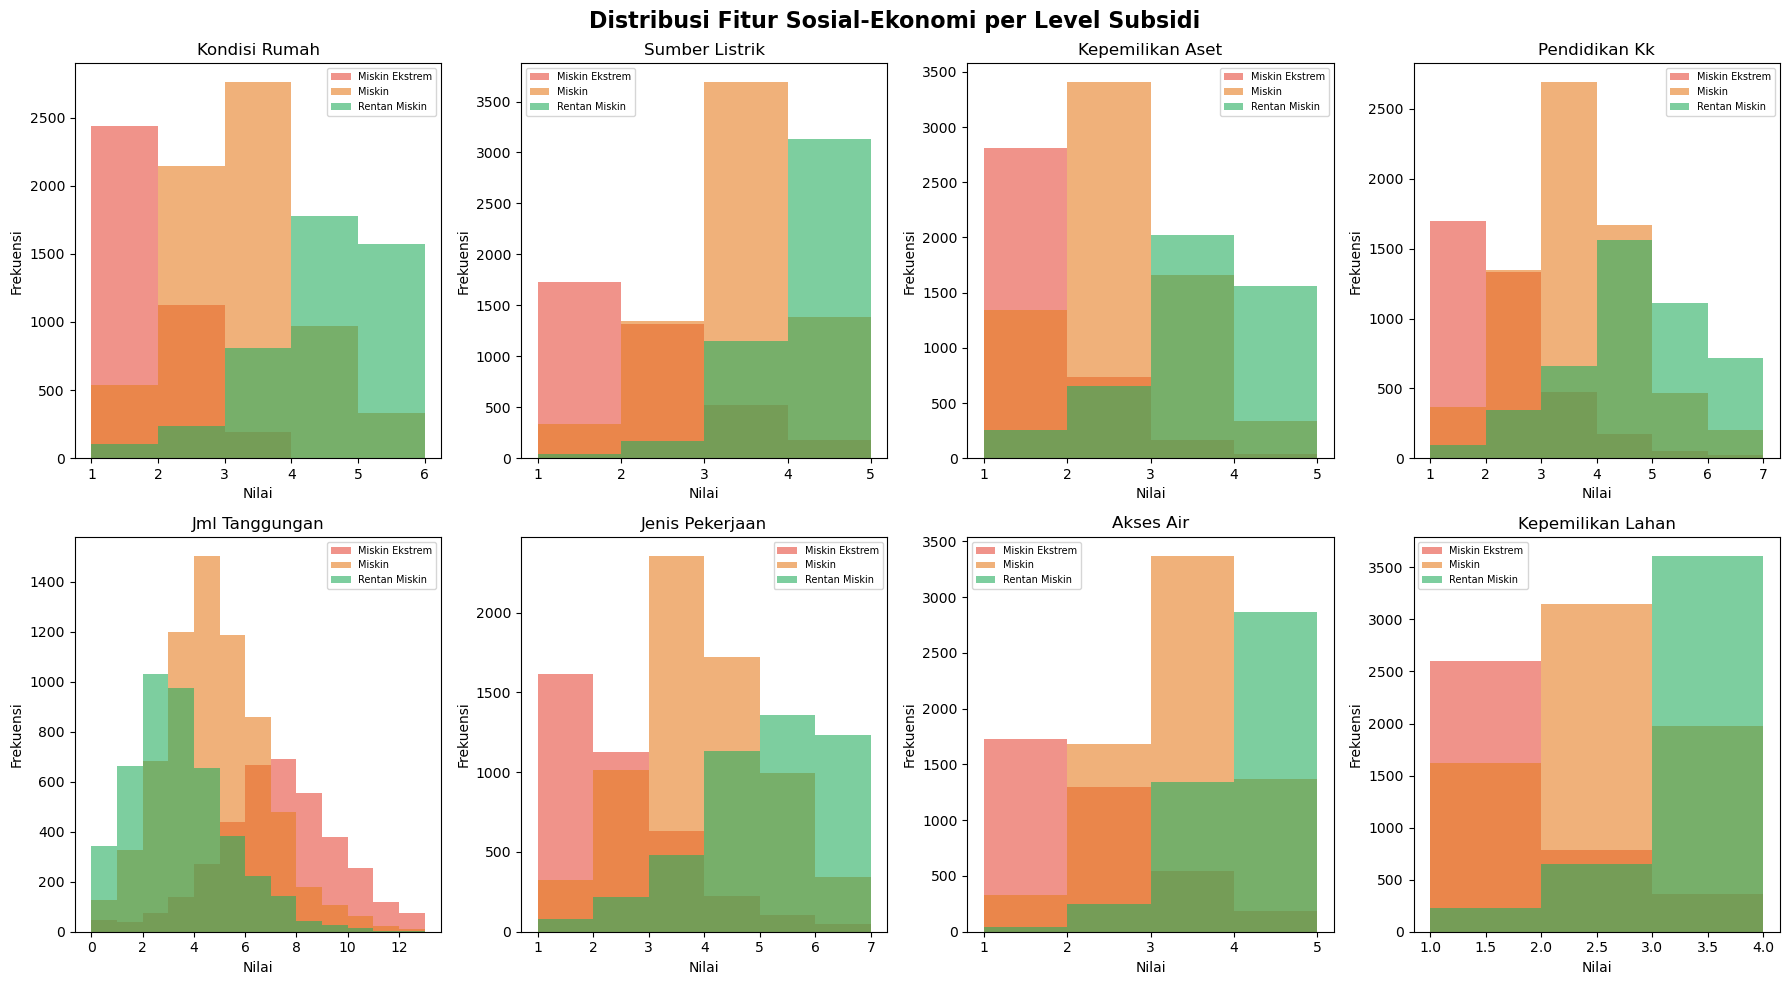

[OK] Plot EDA disimpan


In [94]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Distribusi Fitur Sosial-Ekonomi per Level Subsidi', fontsize=16, fontweight='bold')

features = [
    'kondisi_rumah', 'sumber_listrik', 'kepemilikan_aset', 'pendidikan_kk',
    'jml_tanggungan', 'jenis_pekerjaan', 'akses_air', 'kepemilikan_lahan'
]

labels_map = {1: 'Miskin Ekstrem', 2: 'Miskin', 3: 'Rentan Miskin'}
colors = ['#e74c3c', '#e67e22', '#27ae60']

for ax, feat in zip(axes.flatten(), features):
    for level, color in zip([1, 2, 3], colors):
        subset = df[df['level_subsidi'] == level][feat]
        ax.hist(subset, alpha=0.6, label=labels_map[level], color=color,
                bins=range(int(df[feat].min()), int(df[feat].max()) + 2))
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(fontsize=7)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('../models/eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Plot EDA disimpan')

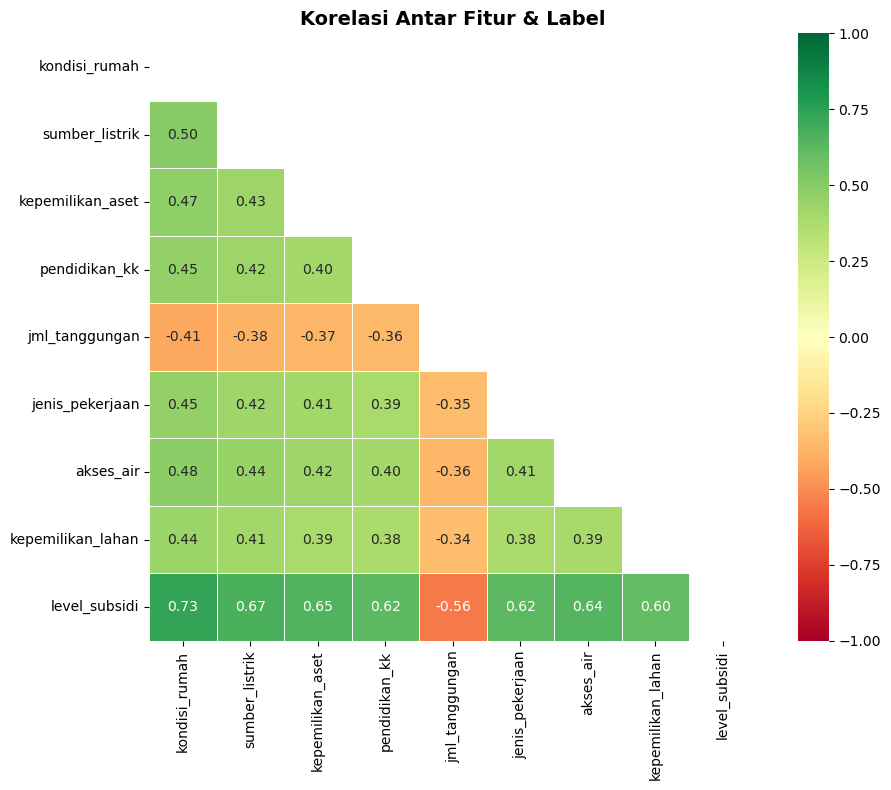

In [95]:
# Heatmap korelasi
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Korelasi Antar Fitur & Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

In [96]:
FEATURE_COLS = [
    'kondisi_rumah', 'sumber_listrik', 'kepemilikan_aset', 'pendidikan_kk',
    'jml_tanggungan', 'jenis_pekerjaan', 'akses_air', 'kepemilikan_lahan'
]
TARGET_COL = 'level_subsidi'

X_base = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# Feature engineering
X = compute_engineered_features(X_base)

# Split stratified: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 15% dari total
)

print(f'Train : {X_train.shape[0]} sampel')
print(f'Val   : {X_val.shape[0]} sampel')
print(f'Test  : {X_test.shape[0]} sampel')
print(f'\nDistribusi kelas train:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Level {u}: {c} ({c/len(y_train)*100:.1f}%)')

Train : 10506 sampel
Val   : 2244 sampel
Test  : 2250 sampel

Distribusi kelas train:
  Level 1: 2626 (25.0%)
  Level 2: 4728 (45.0%)
  Level 3: 3152 (30.0%)


In [97]:
# SMOTE untuk handle imbalance jika ada
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Setelah SMOTE: {X_train_res.shape[0]} sampel')
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Level {u}: {c} ({c/len(y_train_res)*100:.1f}%)')

Setelah SMOTE: 14184 sampel
  Level 1: 4728 (33.3%)
  Level 2: 4728 (33.3%)
  Level 3: 4728 (33.3%)


## 5. Training & Evaluasi — Perbandingan 4 Model

In [98]:
# XGBoost perlu label dimulai dari 0
y_train_xgb = y_train_res - 1
y_val_xgb = y_val - 1
y_test_xgb = y_test - 1

models = {
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=10,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42,
        n_jobs=-1,
        multi_class='ovr',
        C=0.5,
    ),
}

results = {}

for name, model in models.items():
    print(f'\n[OK] Training {name}...')

    # XGBoost pakai label 0-2, sisanya 1-3
    is_xgb = isinstance(model, XGBClassifier)
    _y_train = y_train_xgb if is_xgb else y_train_res
    _y_val   = y_val_xgb   if is_xgb else y_val
    _y_test  = y_test_xgb  if is_xgb else y_test

    model.fit(X_train_res, _y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Koreksi label XGBoost kembali ke 1-3
    if is_xgb:
        y_pred = y_pred + 1
        _y_test_eval = y_test  # Gunakan label asli 1-3 untuk evaluasi
    else:
        _y_test_eval = y_test

    acc = accuracy_score(_y_test_eval, y_pred)
    f1  = f1_score(_y_test_eval, y_pred, average='weighted')
    f1_macro = f1_score(_y_test_eval, y_pred, average='macro')

    results[name] = {
        'model'    : model,
        'accuracy' : acc,
        'f1_weighted': f1,
        'f1_macro' : f1_macro,
        'y_pred'   : y_pred,
        'is_xgb'   : is_xgb,
    }

    print(f'  [OK] Accuracy : {acc:.4f}')
    print(f'     F1 (weighted): {f1:.4f}')
    print(f'     F1 (macro)  : {f1_macro:.4f}')


[OK] Training XGBoost...
  [OK] Accuracy : 0.9333
     F1 (weighted): 0.9334
     F1 (macro)  : 0.9361

[OK] Training LightGBM...
  [OK] Accuracy : 0.9338
     F1 (weighted): 0.9338
     F1 (macro)  : 0.9366

[OK] Training Random Forest...
  [OK] Accuracy : 0.9271
     F1 (weighted): 0.9271
     F1 (macro)  : 0.9303

[OK] Training Logistic Regression...
  [OK] Accuracy : 0.9111
     F1 (weighted): 0.9109
     F1 (macro)  : 0.9150


## 6. Visualisasi Perbandingan Model

In [99]:
# ---- Tabel ringkasan ----
summary_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1 Weighted': f"{res['f1_weighted']:.4f}",
        'F1 Macro': f"{res['f1_macro']:.4f}",
    }
    for name, res in results.items()
]).sort_values('Accuracy', ascending=False)

print('\n>> RINGKASAN PERBANDINGAN MODEL')
print('=' * 65)
print(summary_df.to_string(index=False))
print('\n>> Model terbaik:', summary_df.iloc[0]['Model'])


>> RINGKASAN PERBANDINGAN MODEL
              Model Accuracy F1 Weighted F1 Macro
           LightGBM   0.9338      0.9338   0.9366
            XGBoost   0.9333      0.9334   0.9361
      Random Forest   0.9271      0.9271   0.9303
Logistic Regression   0.9111      0.9109   0.9150

>> Model terbaik: LightGBM


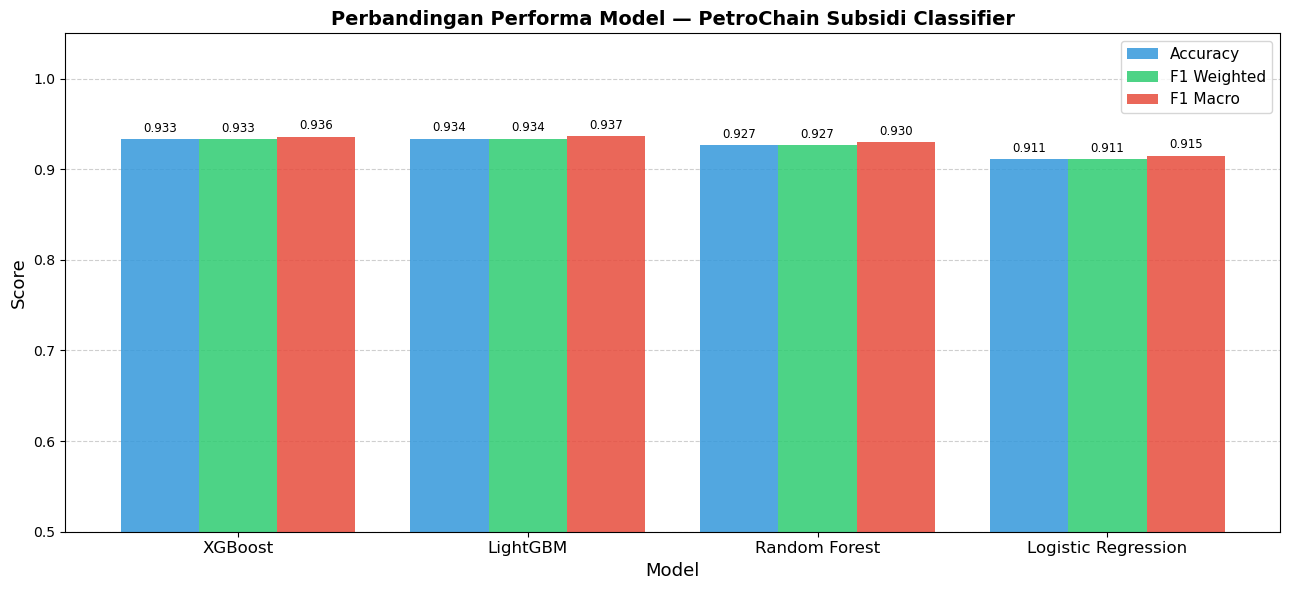

[OK] Plot perbandingan model disimpan


In [100]:
# ---- Bar chart perbandingan ----
model_names = list(results.keys())
accs = [results[n]['accuracy'] for n in model_names]
f1s  = [results[n]['f1_weighted'] for n in model_names]
f1ms = [results[n]['f1_macro'] for n in model_names]

x = np.arange(len(model_names))
width = 0.27

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, accs, width, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x,         f1s,  width, label='F1 Weighted', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + width, f1ms, width, label='F1 Macro', color='#e74c3c', alpha=0.85)

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Perbandingan Performa Model — PetroChain Subsidi Classifier', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Plot perbandingan model disimpan')

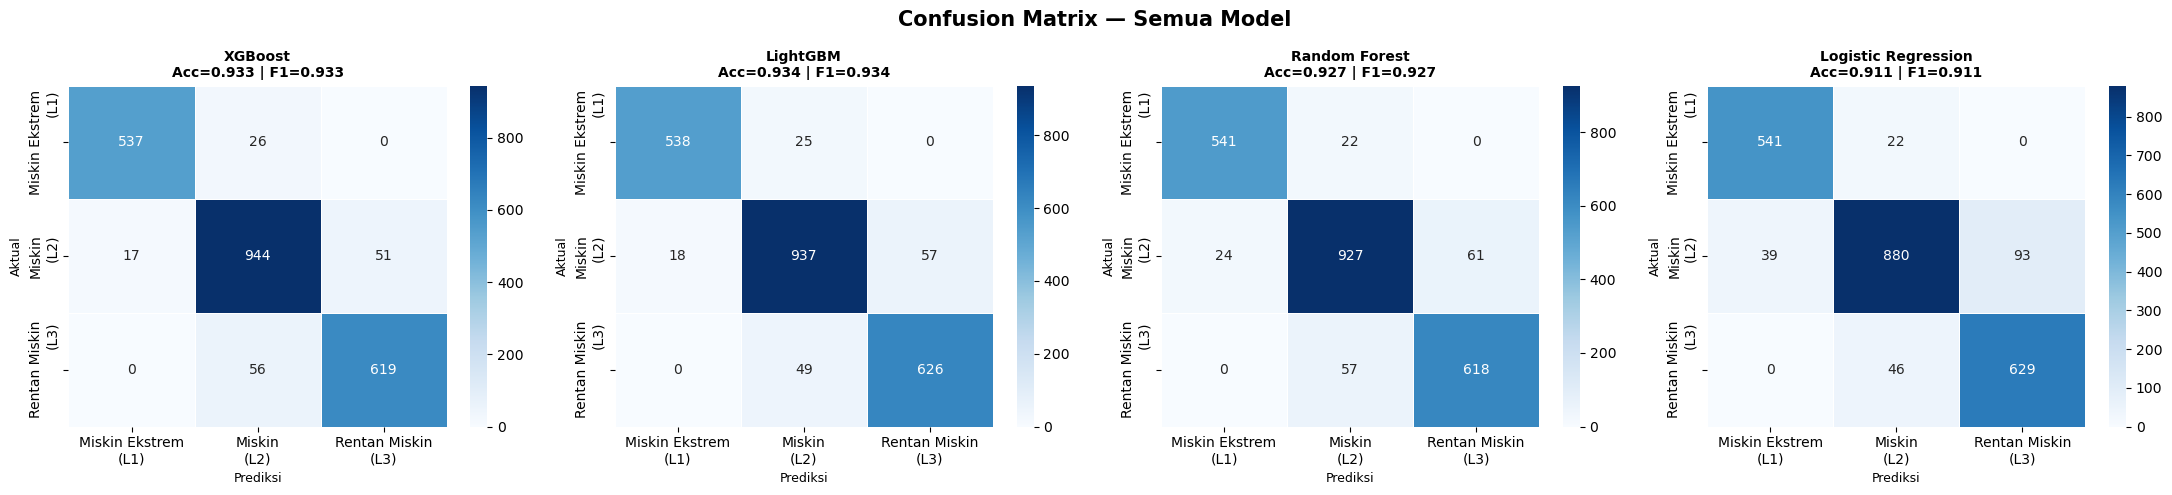

[OK] Confusion matrix disimpan


In [101]:
# ---- Confusion matrix semua model ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrix — Semua Model', fontsize=15, fontweight='bold')

label_names = ['Miskin Ekstrem\n(L1)', 'Miskin\n(L2)', 'Rentan Miskin\n(L3)']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5)
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f} | F1={res["f1_weighted"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual', fontsize=9)

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Confusion matrix disimpan')

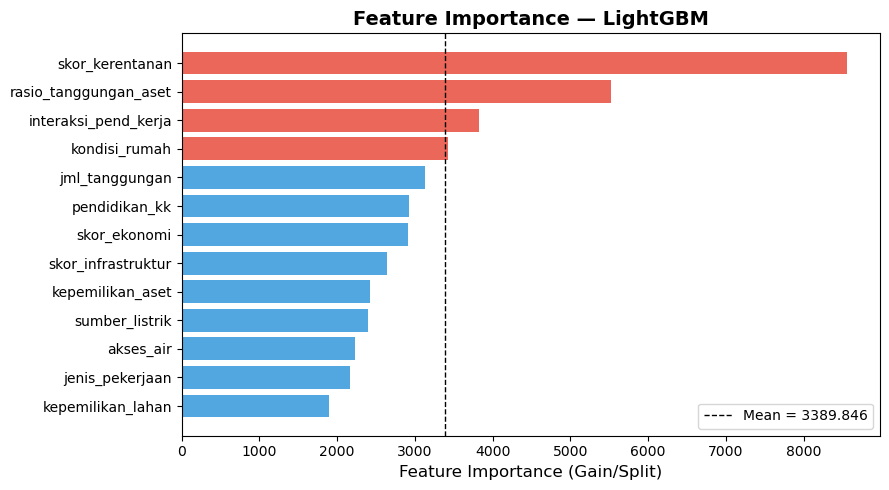

✅ Feature importance disimpan


In [102]:
# ---- Feature importance LightGBM ----
best_model_name = 'LightGBM'
lgbm_model = results[best_model_name]['model']
importances = lgbm_model.feature_importances_

ALL_FEATURES = FEATURE_COLS + [
    'skor_kerentanan', 'rasio_tanggungan_aset', 'skor_infrastruktur',
    'skor_ekonomi', 'interaksi_pend_kerja'
]

feat_imp_df = pd.DataFrame({'Fitur': ALL_FEATURES, 'Importance': importances})\
               .sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = ['#e74c3c' if v > feat_imp_df['Importance'].mean() else '#3498db'
              for v in feat_imp_df['Importance']]
plt.barh(feat_imp_df['Fitur'], feat_imp_df['Importance'], color=colors_imp, alpha=0.85)
plt.xlabel('Feature Importance (Gain/Split)', fontsize=12)
plt.title(f'Feature Importance \u2014 {best_model_name}', fontsize=14, fontweight='bold')
plt.axvline(feat_imp_df['Importance'].mean(), color='black', linestyle='--',
            linewidth=1, label=f'Mean = {feat_imp_df["Importance"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Feature importance disimpan')


In [103]:
# ---- Classification report detail ----
print('\n' + '='*65)
for name, res in results.items():
    print(f'\n Classification Report — {name}')
    print('-'*55)
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Miskin Ekstrem (L1)', 'Miskin (L2)', 'Rentan Miskin (L3)']
    ))



 Classification Report — XGBoost
-------------------------------------------------------
                     precision    recall  f1-score   support

Miskin Ekstrem (L1)       0.97      0.95      0.96       563
        Miskin (L2)       0.92      0.93      0.93      1012
 Rentan Miskin (L3)       0.92      0.92      0.92       675

           accuracy                           0.93      2250
          macro avg       0.94      0.93      0.94      2250
       weighted avg       0.93      0.93      0.93      2250


 Classification Report — LightGBM
-------------------------------------------------------
                     precision    recall  f1-score   support

Miskin Ekstrem (L1)       0.97      0.96      0.96       563
        Miskin (L2)       0.93      0.93      0.93      1012
 Rentan Miskin (L3)       0.92      0.93      0.92       675

           accuracy                           0.93      2250
          macro avg       0.94      0.94      0.94      2250
       weighted avg 

## 7. Cross-Validation (XGBoost)

In [104]:
# 5-fold stratified CV pada seluruh dataset untuk XGBoost
print('>> Running 5-fold Stratified Cross-Validation pada XGBoost...')

X_all = df[FEATURE_COLS].values
y_all = df[TARGET_COL].values - 1  # XGBoost butuh 0-indexed

cv_xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_xgb, X_all, y_all, cv=skf, scoring='accuracy', n_jobs=-1)

print(f'\nCV Accuracy per fold: {cv_scores}')
print(f'Mean Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

>> Running 5-fold Stratified Cross-Validation pada XGBoost...

CV Accuracy per fold: [0.92966667 0.92433333 0.92866667 0.923      0.932     ]
Mean Accuracy : 0.9275 ± 0.0034


## 8. Simpan Model Terbaik ke Disk

In [105]:
# Pilih model dengan F1 weighted tertinggi sebagai model produksi
best_model_name = max(results, key=lambda n: results[n]['f1_weighted'])
best_model = results[best_model_name]['model']

print(f'>> Model terpilih untuk produksi: {best_model_name}')
print(f'   Accuracy  : {results[best_model_name]["accuracy"]:.4f}')
print(f'   F1 Weighted: {results[best_model_name]["f1_weighted"]:.4f}')

# Simpan model utama
model_path = MODEL_DIR / 'petrochain_model.pkl'
joblib.dump(best_model, model_path)
print(f'\n[OK] Model disimpan ke: {model_path.resolve()}')

# Simpan semua model untuk arsip perbandingan
for name, res in results.items():
    safe_name = name.lower().replace(' ', '_')
    path = MODEL_DIR / f'petrochain_{safe_name}.pkl'
    joblib.dump(res['model'], path)
    print(f'   Disimpan : {path.name}')

# Simpan dataset sintetis
df.to_csv(MODEL_DIR / 'synthetic_dataset.csv', index=False)
print(f'\n[OK] Dataset sintetis disimpan ke: {(MODEL_DIR / "synthetic_dataset.csv").resolve()}')

>> Model terpilih untuk produksi: LightGBM
   Accuracy  : 0.9338
   F1 Weighted: 0.9338

[OK] Model disimpan ke: E:\KMIPN\PETROCHAIN\ml-service\models\petrochain_model.pkl
   Disimpan : petrochain_xgboost.pkl
   Disimpan : petrochain_lightgbm.pkl
   Disimpan : petrochain_random_forest.pkl
   Disimpan : petrochain_logistic_regression.pkl

[OK] Dataset sintetis disimpan ke: E:\KMIPN\PETROCHAIN\ml-service\models\synthetic_dataset.csv


## 9. Verifikasi Model — Simulasi Prediksi Produksi

In [106]:
# Load ulang model dan coba predict beberapa skenario realistis
loaded_model = joblib.load(MODEL_DIR / 'petrochain_model.pkl')

FEATURE_ORDER = [
    'kondisi_rumah', 'sumber_listrik', 'kepemilikan_aset', 'pendidikan_kk',
    'jml_tanggungan', 'jenis_pekerjaan', 'akses_air', 'kepemilikan_lahan'
]

LEVEL_QUOTA = {0: (1, 150, 'Miskin Ekstrem'), 1: (2, 80, 'Miskin'), 2: (3, 50, 'Rentan Miskin')}

skenario = [
    # Deskripsi, [kondisi_rumah, sumber_listrik, kepemilikan_aset, pendidikan_kk, jml_tanggungan, jenis_pekerjaan, akses_air, kepemilikan_lahan]
    ('Buruh harian, 6 tanggungan, rumah sangat buruk, sumur gali', [1, 2, 1, 2, 6, 2, 2, 1]),
    ('Nelayan, 4 tanggungan, rumah sedang, PLN prasejahtera',       [3, 3, 2, 2, 4, 3, 3, 2]),
    ('Karyawan, 2 tanggungan, rumah baik, PDAM',                   [4, 4, 3, 4, 2, 6, 4, 3]),
    ('Tidak bekerja, 8 tanggungan, tanpa listrik, tanpa air',      [1, 1, 1, 1, 8, 1, 1, 1]),
    ('Pedagang kecil, 3 tanggungan, rumah cukup',                  [3, 3, 2, 3, 3, 4, 3, 2]),
]

print('>> SIMULASI PREDIKSI PRODUKSI')
print('='*75)
for desc, feats in skenario:
    X_base = np.array([feats], dtype=float)
    X_sim = compute_engineered_features(X_base)
    pred_idx = int(loaded_model.predict(X_sim)[0])

    # Adjust index jika XGBoost (0-indexed)
    if isinstance(loaded_model, XGBClassifier):
        level, kuota, label = LEVEL_QUOTA[pred_idx]
        proba = loaded_model.predict_proba(X_sim)[0][pred_idx]
    else:
        level, kuota, label = LEVEL_QUOTA[pred_idx - 1]
        proba = loaded_model.predict_proba(X_sim)[0][pred_idx - 1]

    print(f'\n• {desc}')
    print(f'  -> Level {level}: {label} | Kuota: {kuota} liter/bulan | Confidence: {proba:.2%}')

print('\n[OK] Verifikasi selesai. Model siap digunakan di produksi.')


>> SIMULASI PREDIKSI PRODUKSI

• Buruh harian, 6 tanggungan, rumah sangat buruk, sumur gali
  -> Level 1: Miskin Ekstrem | Kuota: 150 liter/bulan | Confidence: 99.96%

• Nelayan, 4 tanggungan, rumah sedang, PLN prasejahtera
  -> Level 2: Miskin | Kuota: 80 liter/bulan | Confidence: 99.75%

• Karyawan, 2 tanggungan, rumah baik, PDAM
  -> Level 3: Rentan Miskin | Kuota: 50 liter/bulan | Confidence: 99.99%

• Tidak bekerja, 8 tanggungan, tanpa listrik, tanpa air
  -> Level 1: Miskin Ekstrem | Kuota: 150 liter/bulan | Confidence: 100.00%

• Pedagang kecil, 3 tanggungan, rumah cukup
  -> Level 2: Miskin | Kuota: 80 liter/bulan | Confidence: 99.61%

[OK] Verifikasi selesai. Model siap digunakan di produksi.


---

## Ringkasan

| Item | Detail |
|------|--------|
| Dataset | 5.000 sampel sintetis berbasis distribusi Susenas BPS Aceh |
| Fitur | 8 fitur sosial-ekonomi ordinal |
| Model produksi | Model dengan F1 Weighted tertinggi (lihat sel hasil) |
| Output model | `models/petrochain_model.pkl` |
| Perlu dijalankan ulang? | Saat ada perubahan distribusi data atau threshold level subsidi |

**Langkah selanjutnya:**
1. Install dependencies: `pip install -r requirements.txt`
2. Jalankan notebook ini untuk generate model `.pkl`
3. Jalankan FastAPI service: `uvicorn app.main:app --reload --port 8000`
4. Test endpoint: `POST http://localhost:8000/predict`